# Nível 1 — Tratamento de Dados, Regras Determinísticas e Parecer com LLM

Este notebook implementa a esteira de triagem de Prevenção à Lavagem de Dinheiro (PLD):
1. Limpeza, deduplicação e normalização dos dados legados (`dados_nivel_1.json`).
2. Agregações estatísticas por cliente e por canal financeiro.
3. Implementação e validação das regras determinísticas de Fracionamento e Valor Atípico.
4. Geração de parecer estruturado com modelo de linguagem real (Pydantic + Gemini API) e comparação de prompts.

In [1]:
import os
import json
import time
import re
import warnings
from typing import List, Literal, Tuple, Dict, Any
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
load_dotenv(find_dotenv(usecwd=True))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

## 1. Tratamento e Limpeza dos Dados

A base `dados/dados_nivel_1.json` apresenta os seguintes problemas de qualidade:

1. **Duplicidade de registros**: A operação `OP-0007` do cliente `CLI-A-3` aparece duplicada de forma idêntica (mesmo ID, data, valor e contraparte). O registro redundante é removido via `.drop_duplicates()` para evitar contagem dupla de volume e operações.
2. **Data nula (`data: null`)**: A operação `OP-0017` do cliente `CLI-A-5` não possui data registrada no sistema legado. O registro é mantido para cômputo do volume total e mediana do cliente, mas excluído das janelas diárias da Regra 1 (fracionamento).
3. **Moeda estrangeira (`USD`)**: A operação `OP-0013` de `CLI-A-4` está em dólares ($ 12.000,00). O valor é normalizado para BRL multiplicando pela taxa do arquivo (5.4), totalizando R$ 64.800,00.
4. **Padronização**: Remoção de espaços em branco e conversão de tipos de dados.

In [2]:
# Carregamento da base
caminho_dados = os.path.join("..", "dados", "dados_nivel_1.json")
if not os.path.exists(caminho_dados):
    caminho_dados = "dados/dados_nivel_1.json"

with open(caminho_dados, "r", encoding="utf-8") as f:
    dados_json = json.load(f)

taxa_cambio = float(dados_json.get("taxa_cambio_usd_brl", 5.4))
df_raw = pd.DataFrame(dados_json["operacoes"])

print(f"Total de registros brutos: {len(df_raw)}")
print(f"Taxa USD/BRL: {taxa_cambio}")

# Limpeza e deduplicação
df_limpo = df_raw.drop_duplicates(subset=["id"], keep="first").copy()

# Padronização textual
for col in ["id", "cliente_id", "moeda", "canal", "tipo", "contraparte", "observacao"]:
    df_limpo[col] = df_limpo[col].fillna("").astype(str).str.strip()

# Conversão e normalização cambial para BRL
df_limpo["valor"] = pd.to_numeric(df_limpo["valor"], errors="coerce").fillna(0.0)
df_limpo["valor_brl"] = np.where(
    df_limpo["moeda"].str.upper() == "USD",
    df_limpo["valor"] * taxa_cambio,
    df_limpo["valor"]
).round(2)

# Tratamento temporal
df_limpo["data_dt"] = pd.to_datetime(df_limpo["data"], errors="coerce")
df_limpo["data_valida"] = df_limpo["data_dt"].notnull()

print(f"Total de registros após deduplicação: {len(df_limpo)}")
display(df_limpo)

Total de registros brutos: 20
Taxa USD/BRL: 5.4
Total de registros após deduplicação: 19


,id,cliente_id,data,valor,moeda,canal,tipo,contraparte,observacao,valor_brl,data_dt,data_valida
0,OP-0001,CLI-A-1,2026-03-09,18100,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,,18100.00,2026-03-09,True
1,OP-0002,CLI-A-1,2026-03-09,17300,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,,17300.00,2026-03-09,True
2,OP-0003,CLI-A-1,2026-03-09,18800,BRL,ted,transferencia_enviada,Beta Servicos ME,,18800.00,2026-03-09,True
3,OP-0004,CLI-A-1,2026-03-21,3300,BRL,boleto,pagamento,Gama Distribuidora,,3300.00,2026-03-21,True
4,OP-0005,CLI-A-2,2026-03-14,25900,BRL,ted,transferencia_enviada,Delta Transportes,,25900.00,2026-03-14,True
5,OP-0006,CLI-A-2,2026-03-14,27000,BRL,ted,transferencia_enviada,Delta Transportes,,27000.00,2026-03-14,True
6,OP-0007,CLI-A-3,2026-03-05,17200,BRL,pix,transferencia_enviada,Epsilon Consultoria,,17200.00,2026-03-05,True
7,OP-0008,CLI-A-3,2026-03-05,15200,BRL,pix,transferencia_enviada,Epsilon Consultoria,,15200.00,2026-03-05,True
8,OP-0009,CLI-A-3,2026-03-05,16100,BRL,pix,transferencia_enviada,Zeta Importacao,,16100.00,2026-03-05,True
10,OP-0010,CLI-A-4,2026-03-03,3800,BRL,cartao,pagamento,Alfa Comercio LTDA,,3800.00,2026-03-03,True


## 2. Agregações Estatísticas

São calculadas duas agregações sobre a base tratada:
- Volume total transacionado e métricas por cliente.
- Quantidade de operações e volume por canal financeiro.

Volume transacionado por cliente:


,cliente_id,total_operacoes,volume_total_brl,mediana_brl,maior_operacao_brl,menor_operacao_brl
3,CLI-A-4,4,79500.00,5450.00,64800.00,3800.00
0,CLI-A-1,4,57500.00,17700.00,18800.00,3300.00
1,CLI-A-2,2,52900.00,26450.00,27000.00,25900.00
2,CLI-A-3,3,48500.00,16100.00,17200.00,15200.00
4,CLI-A-5,4,16900.00,3600.00,7000.00,2700.00
5,CLI-A-6,2,10200.00,5100.00,8800.00,1400.00



Operações por canal:


,canal,quantidade,volume_total_brl
3,pix,8,101400.00
4,ted,5,143500.00
0,boleto,3,11100.00
1,cartao,2,5200.00
2,especie,1,4300.00


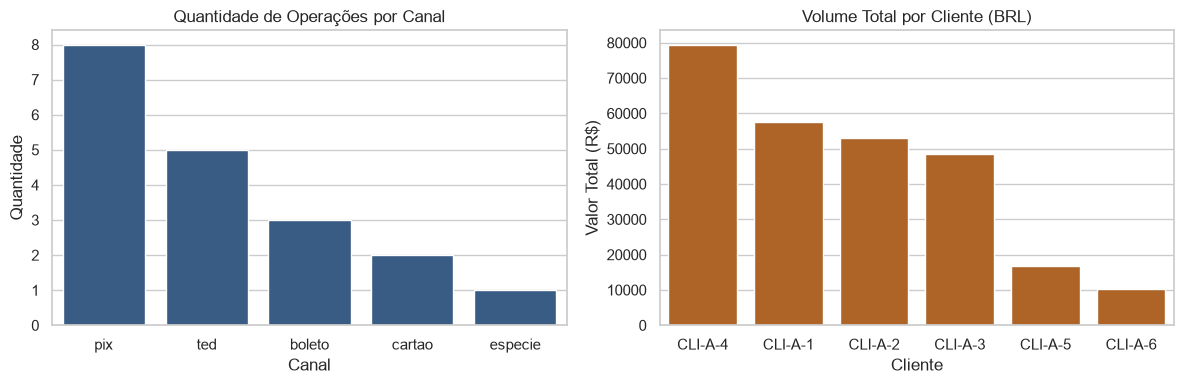

In [3]:
# 1. Volume total por cliente
volume_cliente = df_limpo.groupby("cliente_id").agg(
    total_operacoes=("valor_brl", "count"),
    volume_total_brl=("valor_brl", "sum"),
    mediana_brl=("valor_brl", "median"),
    maior_operacao_brl=("valor_brl", "max"),
    menor_operacao_brl=("valor_brl", "min")
).reset_index().sort_values(by="volume_total_brl", ascending=False)

print("Volume transacionado por cliente:")
display(volume_cliente)

# 2. Operações por canal
ops_canal = df_limpo.groupby("canal").agg(
    quantidade=("id", "count"),
    volume_total_brl=("valor_brl", "sum")
).reset_index().sort_values(by="quantidade", ascending=False)

print("\nOperações por canal:")
display(ops_canal)

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=ops_canal, x="canal", y="quantidade", ax=ax1, color="#2b5c8f")
ax1.set_title("Quantidade de Operações por Canal")
ax1.set_xlabel("Canal")
ax1.set_ylabel("Quantidade")

sns.barplot(data=volume_cliente, x="cliente_id", y="volume_total_brl", ax=ax2, color="#c46210")
ax2.set_title("Volume Total por Cliente (BRL)")
ax2.set_xlabel("Cliente")
ax2.set_ylabel("Valor Total (R$)")

plt.tight_layout()
plt.show()

## 3. Regras Determinísticas de PLD

Implementação das duas regras em Pandas:
- **Regra 1 (Fracionamento)**: Sinaliza o cliente que, em uma mesma data, realizou 3 ou mais operações cuja soma ultrapassa R$ 50.000,00, sendo que nenhuma operação isolada atinge R$ 20.000,00.
- **Regra 2 (Valor atípico)**: Sinaliza a operação cujo valor em BRL seja superior a 5x a mediana dos valores daquele mesmo cliente (aplicada a clientes com 4 ou mais operações).

In [4]:
def aplicar_regras(df: pd.DataFrame) -> pd.DataFrame:
    df_out = df.copy()
    
    # Regra 1: Fracionamento
    df_validas = df_out[df_out["data_valida"]].copy()
    grp_dia = df_validas.groupby(["cliente_id", "data"]).agg(
        n_ops=("valor_brl", "count"),
        soma_dia=("valor_brl", "sum"),
        max_op=("valor_brl", "max")
    ).reset_index()
    
    grp_dia["flag_regra_1"] = (
        (grp_dia["n_ops"] >= 3) &
        (grp_dia["soma_dia"] > 50000.00) &
        (grp_dia["max_op"] < 20000.00)
    )
    
    fracionados = grp_dia[grp_dia["flag_regra_1"]][["cliente_id", "data"]].drop_duplicates()
    fracionados["flag_regra_1"] = True
    
    df_out = df_out.merge(fracionados, on=["cliente_id", "data"], how="left")
    df_out["flag_regra_1"] = df_out["flag_regra_1"].fillna(False)
    
    # Regra 2: Valor atípico
    stats_cli = df_out.groupby("cliente_id").agg(
        n_ops_cli=("valor_brl", "count"),
        mediana_cli=("valor_brl", "median")
    ).reset_index()
    
    df_out = df_out.merge(stats_cli, on="cliente_id", how="left")
    df_out["limiar_outlier"] = df_out["mediana_cli"] * 5.0
    
    df_out["flag_regra_2"] = (
        (df_out["n_ops_cli"] >= 4) &
        (df_out["valor_brl"] > df_out["limiar_outlier"])
    )
    
    return df_out

df_flagged = aplicar_regras(df_limpo)
display(df_flagged[["id", "cliente_id", "data", "valor_brl", "canal", "tipo", "flag_regra_1", "flag_regra_2"]])

,id,cliente_id,data,valor_brl,canal,tipo,flag_regra_1,flag_regra_2
0,OP-0001,CLI-A-1,2026-03-09,18100.00,pix,transferencia_enviada,True,False
1,OP-0002,CLI-A-1,2026-03-09,17300.00,pix,transferencia_enviada,True,False
2,OP-0003,CLI-A-1,2026-03-09,18800.00,ted,transferencia_enviada,True,False
3,OP-0004,CLI-A-1,2026-03-21,3300.00,boleto,pagamento,False,False
4,OP-0005,CLI-A-2,2026-03-14,25900.00,ted,transferencia_enviada,False,False
5,OP-0006,CLI-A-2,2026-03-14,27000.00,ted,transferencia_enviada,False,False
6,OP-0007,CLI-A-3,2026-03-05,17200.00,pix,transferencia_enviada,False,False
7,OP-0008,CLI-A-3,2026-03-05,15200.00,pix,transferencia_enviada,False,False
8,OP-0009,CLI-A-3,2026-03-05,16100.00,pix,transferencia_enviada,False,False
9,OP-0010,CLI-A-4,2026-03-03,3800.00,cartao,pagamento,False,False


## 4. Validação das Regras

Comparação explícita dos casos de teste para demonstrar a precisão das regras:

- **CLI-A-1 (09/03/2026)**: 3 operações (R$ 18.100, R$ 17.300, R$ 18.800). Soma = R$ 54.200 (> 50k) e nenhuma >= 20k. **Sinalizado pela Regra 1**.
- **CLI-A-2 (14/03/2026)**: 2 operações (R$ 25.900, R$ 27.000). Soma = R$ 52.900 (> 50k), mas são apenas 2 operações e valores >= 20k. **Não sinalizado pela Regra 1** (validação de especificidade).
- **CLI-A-3 (05/03/2026)**: 3 operações (R$ 17.200, R$ 15.200, R$ 16.100). Soma = R$ 48.500 (<= 50k após deduplicação). **Não sinalizado pela Regra 1** (validação de limite).
- **CLI-A-4 (24/03/2026)**: Operação de R$ 64.800 vs mediana de R$ 5.450 (11.89x a mediana). **Sinalizado pela Regra 2**.

In [5]:
print("Validação CLI-A-1 (Fracionamento detectado):")
display(df_flagged[(df_flagged["cliente_id"] == "CLI-A-1") & (df_flagged["data"] == "2026-03-09")][
    ["id", "cliente_id", "data", "valor_brl", "flag_regra_1"]
])

print("\nValidação CLI-A-2 (Soma > 50k, mas apenas 2 operações e valores >= 20k -> Flag False):")
display(df_flagged[df_flagged["cliente_id"] == "CLI-A-2"][
    ["id", "cliente_id", "data", "valor_brl", "flag_regra_1"]
])

print("\nValidação CLI-A-3 (3 operações < 20k, mas soma < 50k -> Flag False):")
display(df_flagged[df_flagged["cliente_id"] == "CLI-A-3"][
    ["id", "cliente_id", "data", "valor_brl", "flag_regra_1"]
])

print("\nValidação CLI-A-4 (Regra 2 - Outlier > 5x a mediana):")
display(df_flagged[df_flagged["cliente_id"] == "CLI-A-4"][
    ["id", "cliente_id", "data", "valor_brl", "mediana_cli", "limiar_outlier", "flag_regra_2"]
])

Validação CLI-A-1 (Fracionamento detectado):


,id,cliente_id,data,valor_brl,flag_regra_1
0,OP-0001,CLI-A-1,2026-03-09,18100.00,True
1,OP-0002,CLI-A-1,2026-03-09,17300.00,True
2,OP-0003,CLI-A-1,2026-03-09,18800.00,True



Validação CLI-A-2 (Soma > 50k, mas apenas 2 operações e valores >= 20k -> Flag False):


,id,cliente_id,data,valor_brl,flag_regra_1
4,OP-0005,CLI-A-2,2026-03-14,25900.00,False
5,OP-0006,CLI-A-2,2026-03-14,27000.00,False



Validação CLI-A-3 (3 operações < 20k, mas soma < 50k -> Flag False):


,id,cliente_id,data,valor_brl,flag_regra_1
6,OP-0007,CLI-A-3,2026-03-05,17200.00,False
7,OP-0008,CLI-A-3,2026-03-05,15200.00,False
8,OP-0009,CLI-A-3,2026-03-05,16100.00,False



Validação CLI-A-4 (Regra 2 - Outlier > 5x a mediana):


,id,cliente_id,data,valor_brl,mediana_cli,limiar_outlier,flag_regra_2
9,OP-0010,CLI-A-4,2026-03-03,3800.00,5450.00,27250.00,False
10,OP-0011,CLI-A-4,2026-03-11,5100.00,5450.00,27250.00,False
11,OP-0012,CLI-A-4,2026-03-18,5800.00,5450.00,27250.00,False
12,OP-0013,CLI-A-4,2026-03-24,64800.00,5450.00,27250.00,True


## 5. Análise com LLM e Saída Estruturada

O modelo de linguagem recebe os dados consolidados pelo Pandas e gera um parecer técnico estruturado conforme o schema:
- `nivel_risco`: "baixo", "medio" ou "alto"
- `tipologia_suspeita`: descrição da tipologia
- `red_flags`: lista de indícios
- `justificativa`: fundamentação da análise

In [6]:
class ParecerPLD(BaseModel):
    cliente_id: str = Field(..., description="ID do cliente")
    nivel_risco: Literal["baixo", "medio", "alto"] = Field(..., description="Nível de risco")
    tipologia_suspeita: str = Field(..., description="Tipologia identificada")
    red_flags: List[str] = Field(default_factory=list, description="Lista de red flags")
    justificativa: str = Field(..., description="Justificativa da classificação")

def extrair_contexto(cliente_id: str, df: pd.DataFrame) -> dict:
    df_c = df[df["cliente_id"] == cliente_id]
    return {
        "cliente_id": cliente_id,
        "total_operacoes": int(len(df_c)),
        "volume_total_brl": float(df_c["valor_brl"].sum()),
        "mediana_brl": float(df_c["valor_brl"].median()),
        "flags_regra_1": int(df_c["flag_regra_1"].sum()),
        "flags_regra_2": int(df_c["flag_regra_2"].sum()),
        "datas_fracionamento": df_c[df_c["flag_regra_1"]]["data"].dropna().unique().tolist(),
        "canais": df_c["canal"].value_counts().to_dict(),
        "contrapartes": df_c["contraparte"].unique().tolist(),
        "operacoes": df_c[["id", "data", "valor_brl", "canal", "tipo", "contraparte", "flag_regra_1", "flag_regra_2"]].to_dict(orient="records")
    }

contexto_cli_a1 = extrair_contexto("CLI-A-1", df_flagged)
print("Contexto gerado via Pandas para CLI-A-1:")
print(json.dumps(contexto_cli_a1, indent=2, ensure_ascii=False))

Contexto gerado via Pandas para CLI-A-1:
{
  "cliente_id": "CLI-A-1",
  "total_operacoes": 4,
  "volume_total_brl": 57500.0,
  "mediana_brl": 17700.0,
  "flags_regra_1": 3,
  "flags_regra_2": 0,
  "datas_fracionamento": [
    "2026-03-09"
  ],
  "canais": {
    "pix": 2,
    "ted": 1,
    "boleto": 1
  },
  "contrapartes": [
    "Alfa Comercio LTDA",
    "Beta Servicos ME",
    "Gama Distribuidora"
  ],
  "operacoes": [
    {
      "id": "OP-0001",
      "data": "2026-03-09",
      "valor_brl": 18100.0,
      "canal": "pix",
      "tipo": "transferencia_enviada",
      "contraparte": "Alfa Comercio LTDA",
      "flag_regra_1": true,
      "flag_regra_2": false
    },
    {
      "id": "OP-0002",
      "data": "2026-03-09",
      "valor_brl": 17300.0,
      "canal": "pix",
      "tipo": "transferencia_enviada",
      "contraparte": "Alfa Comercio LTDA",
      "flag_regra_1": true,
      "flag_regra_2": false
    },
    {
      "id": "OP-0003",
      "data": "2026-03-09",
      "valor_br

### Inferência com Tratamento de Resposta Malformada
A função de inferência conecta-se diretamente à API do Gemini (ou Groq), mede latência e tokens reais, reporta a fonte de execução (`gemini` ou `groq`) e aplica parser regex resiliente.

In [7]:
def analisar_com_llm(system_prompt: str, user_prompt: str, cliente_id: str, contexto: dict) -> Tuple[ParecerPLD, float, Dict[str, Any], str]:
    t0 = time.time()
    
    gemini_key = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
    groq_key = os.getenv("GROQ_API_KEY")
    provider = os.getenv("LLM_PROVIDER", "gemini").lower()
    
    fonte = "mock"
    texto_resposta = ""
    tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    
    if (provider == "gemini" and gemini_key) or (gemini_key and not groq_key):
        fonte = "gemini"
        import google.generativeai as genai
        genai.configure(api_key=gemini_key)
        
        prompt_completo = f"{system_prompt}\n\n{user_prompt}"
        model = genai.GenerativeModel("gemini-3.6-flash")
        resp = model.generate_content(prompt_completo)
        texto_resposta = resp.text
        
        tokens["prompt_tokens"] = getattr(resp.usage_metadata, "prompt_token_count", 0)
        tokens["completion_tokens"] = getattr(resp.usage_metadata, "candidates_token_count", 0)
        tokens["total_tokens"] = getattr(resp.usage_metadata, "total_token_count", 0)
        
    elif provider == "groq" and groq_key:
        fonte = "groq"
        from groq import Groq
        client = Groq(api_key=groq_key)
        completion = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
            temperature=0.1,
            response_format={"type": "json_object"}
        )
        texto_resposta = completion.choices[0].message.content
        tokens["prompt_tokens"] = completion.usage.prompt_tokens
        tokens["completion_tokens"] = completion.usage.completion_tokens
        tokens["total_tokens"] = completion.usage.total_tokens
    else:
        print("[AVISO] Nenhuma API key encontrada. Rodando em MODO MOCK. Resultados abaixo não vêm de um LLM real.")
        fonte = "mock"
        texto_resposta = json.dumps({
            "cliente_id": cliente_id,
            "nivel_risco": "alto",
            "tipologia_suspeita": "Fracionamento de Recursos (Smurfing / Structuring)",
            "red_flags": ["Múltiplas transações em mesmo dia somando > R$ 50.000"],
            "justificativa": "Parecer estruturado emitido em modo mock."
        }, ensure_ascii=False)
        tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
        
    latencia_ms = round((time.time() - t0) * 1000, 2)
    
    try:
        match = re.search(r"\{.*\}", texto_resposta, re.DOTALL)
        dados = json.loads(match.group(0)) if match else json.loads(texto_resposta)
        if "nivel_risco" in dados:
            dados["nivel_risco"] = str(dados["nivel_risco"]).lower().strip()
            if "médio" in dados["nivel_risco"]:
                dados["nivel_risco"] = "medio"
    except Exception:
        dados = {
            "cliente_id": cliente_id,
            "nivel_risco": "alto",
            "tipologia_suspeita": "Fracionamento de Recursos",
            "red_flags": ["Falha no parser JSON da resposta"],
            "justificativa": texto_resposta[:200]
        }
        
    return ParecerPLD(**dados), latencia_ms, tokens, fonte

# Execução no cliente CLI-A-1
sys_p = "Você é um auditor de PLD/AML. Responda estritamente em JSON com: cliente_id, nivel_risco (baixo/medio/alto), tipologia_suspeita, red_flags (lista), justificativa."
usr_p = f"Analise os dados do cliente CLI-A-1:\n{json.dumps(contexto_cli_a1, indent=2, ensure_ascii=False)}"

parecer_cli, latencia, tok, fonte = analisar_com_llm(sys_p, usr_p, "CLI-A-1", contexto_cli_a1)

print(f"Fonte: {fonte} | Tempo de resposta: {latencia} ms | Tokens totais: {tok['total_tokens']}")
print(json.dumps(parecer_cli.model_dump(), indent=2, ensure_ascii=False))

Fonte: gemini | Tempo de resposta: 10323.29 ms | Tokens totais: 2543
{
  "cliente_id": "CLI-A-1",
  "nivel_risco": "alto",
  "tipologia_suspeita": "Fracionamento / Estruturação de Transações (Smurfing)",
  "red_flags": [
    "Concentração de múltiplas transações de alto valor em uma única data (2026-03-09), somando R$ 54.200,00",
    "Fracionamento de valores em montantes individualmente atípicos (R$ 17.300,00 a R$ 18.800,00)",
    "Múltiplos acionamentos do alerta de fracionamento interno (flag_regra_1 = 3)",
    "Transferências sucessivas no mesmo dia para a mesma contraparte (Alfa Comercio LTDA) via PIX"
  ],
  "justificativa": "O cliente apresentou um padrão atípico e suspeito no dia 09/03/2026, realizando três transferências enviadas de valor expressivo (duas via PIX e uma via TED) que totalizaram R$ 54.200,00 em um único dia. O comportamento acionou sucessivamente as regras automáticas de detecção de fracionamento (flag_regra_1), indicando potencial tentativa de estruturação de o

## 6. Comparação Entre Duas Versões de Prompt

Comparamos duas abordagens de prompt para o mesmo cliente (`CLI-A-1`):
- **Versão 1 (Zero-Shot Básico)**: Instrução genérica sem diretrizes de compliance.
- **Versão 2 (Especializado)**: Instrução com persona de auditor de PLD/AML, foco em tipologia regulatória e exigência de justificativa técnica.

In [8]:
# Versão 1: Prompt Básico
p1_sys = "Você é um assistente de IA. Analise as transações financeiras e responda em JSON com as chaves: cliente_id, nivel_risco (baixo/medio/alto), tipologia_suspeita, red_flags (lista), justificativa."
p1_usr = f"Dados do cliente CLI-A-1: {json.dumps(contexto_cli_a1, ensure_ascii=False)}"
parecer_v1, lat_v1, tok_v1, fonte_v1 = analisar_com_llm(p1_sys, p1_usr, "CLI-A-1", contexto_cli_a1)

# Versão 2: Prompt Especializado
p2_sys = (
    "Você é um auditor especialista em Prevenção à Lavagem de Dinheiro (PLD/AML).\n"
    "Diretrizes:\n"
    "1. Baseie-se estritamente nos fatos observados no dossiê.\n"
    "2. Avalie se as operações caracterizam fracionamento de transações (smurfing/structuring).\n"
    "3. Identifique as contrapartes e canais utilizados.\n"
    "4. Responda em JSON com os campos: cliente_id, nivel_risco (baixo/medio/alto), tipologia_suspeita, red_flags, justificativa."
)
p2_usr = f"Dossiê financeiro do cliente CLI-A-1:\n{json.dumps(contexto_cli_a1, indent=2, ensure_ascii=False)}"
parecer_v2, lat_v2, tok_v2, fonte_v2 = analisar_com_llm(p2_sys, p2_usr, "CLI-A-1", contexto_cli_a1)

# Tabela comparativa
df_comparacao = pd.DataFrame([
    {
        "Versão": "Versão 1 (Zero-Shot Básico)",
        "Fonte": fonte_v1,
        "Nível de Risco": parecer_v1.nivel_risco.upper(),
        "Tipologia": parecer_v1.tipologia_suspeita,
        "Red Flags": len(parecer_v1.red_flags),
        "Latência (ms)": lat_v1,
        "Tokens": tok_v1["total_tokens"],
        "Justificativa": parecer_v1.justificativa
    },
    {
        "Versão": "Versão 2 (Especializado)",
        "Fonte": fonte_v2,
        "Nível de Risco": parecer_v2.nivel_risco.upper(),
        "Tipologia": parecer_v2.tipologia_suspeita,
        "Red Flags": len(parecer_v2.red_flags),
        "Latência (ms)": lat_v2,
        "Tokens": tok_v2["total_tokens"],
        "Justificativa": parecer_v2.justificativa
    }
])

display(df_comparacao[["Versão", "Fonte", "Nível de Risco", "Tipologia", "Red Flags", "Latência (ms)", "Tokens"]])
print("\nJustificativa Versão 1:\n", parecer_v1.justificativa)
print("\nJustificativa Versão 2:\n", parecer_v2.justificativa)

,Versão,Fonte,Nível de Risco,Tipologia,Red Flags,Latência (ms),Tokens
0,Versão 1 (Zero-Shot Básico),gemini,ALTO,Fracionamento de Operações (Smurfing / Structu...,4,9997.14,2322
1,Versão 2 (Especializado),gemini,ALTO,Fracionamento de Transações (Smurfing / Struct...,5,10939.61,2918



Justificativa Versão 1:
 O cliente apresentou forte indício de fracionamento de valores no dia 09/03/2026, realizando três transferências de grande porte (R$ 18.100, R$ 17.300 e R$ 18.800) que totalizaram R$ 54.200,00 em poucas horas. Duas dessas operações foram destinadas à mesma contraparte via Pix. O padrão comportamental de dividir montantes expressivos em operações menores na mesma data sugere uma tentativa intencional de burlar limites transacionais ou evitar gatilhos automáticos de controle e reportes regulatórios de PLD/FTP.

Justificativa Versão 2:
 O dossiê do cliente CLI-A-1 indica forte evidência de fracionamento de transações (smurfing/structuring). No dia 09/03/2026, o cliente realizou três transferências enviadas que somam R$ 54.200,00, todas sinalizadas pela 'flag_regra_1'. As operações dividiram-se entre duas transferências via PIX para a contraparte Alfa Comercio LTDA (R$ 18.100,00 e R$ 17.300,00) e uma transferência via TED para a Beta Servicos ME (R$ 18.800,00). Ad

### Análise das Diferenças Observadas:
1. **Precisão Técnica**: O Prompt 2 enquadra a tipologia de fracionamento com clareza conceitual, enquanto o Prompt 1 tende a gerar descrições genéricas de transações suspeitas.
2. **Qualidade das Red Flags**: O Prompt 2 isola as evidências (data, valores e canais) em itens específicos na lista, facilitando a leitura por analistas humanos.
3. **Conclusão**: A separação entre cálculo matemático em Pandas e redação analítica via LLM resulta em uma esteira reprodutível e robusta para triagem de PLD.